In [1]:
import wandb
import pandas as pd

In [2]:
api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\emper\_netrc.


In [3]:
runs = api.runs("pavaris_asawa-vistec/KEY-SENSOR")
print(f"Found {len(runs)} runs")


Found 175 runs


In [10]:
label_map = {
    "pos" : "Pos",
    "pos_vel" : "Pos+Vel",
    "pos_action": "Pos+Act",
    "vel": "Vel",    
    "vel_action": "Vel+Act",
    "action": "Act",
    "pos_vel_action": "Pos+Vel+Act",
}

NUM_RUNS = 5

In [11]:
runs_by_name = {run.name: run for run in runs}

data = {}
records = []

for sensor in label_map.keys():
    data[sensor] = {}
    for run_num in range(NUM_RUNS):
        run_name = f"HEBB-{sensor}-{run_num}"
        run = runs_by_name.get(run_name)
        if run is None:
            print(f"Warning: run not found: {run_name}")
            continue

        hist = run.history(keys=["mean"])
        data[sensor][run_num] = hist

        for _, row in hist.iterrows():
            records.append({
                "sensor": sensor,
                "run_num": run_num,
                "step": row.get("_step"),
                "mean": row["mean"],
            })

mean_df = pd.DataFrame(records)
print(f"Collected {len(mean_df)} rows across {mean_df['sensor'].nunique()} sensors")
mean_df.head()

Collected 3535 rows across 7 sensors


,sensor,run_num,step,mean
0,pos,0,0.0,-10.721514
1,pos,0,1.0,-9.059509
2,pos,0,2.0,-3.189160
3,pos,0,3.0,0.044175
4,pos,0,4.0,0.678399


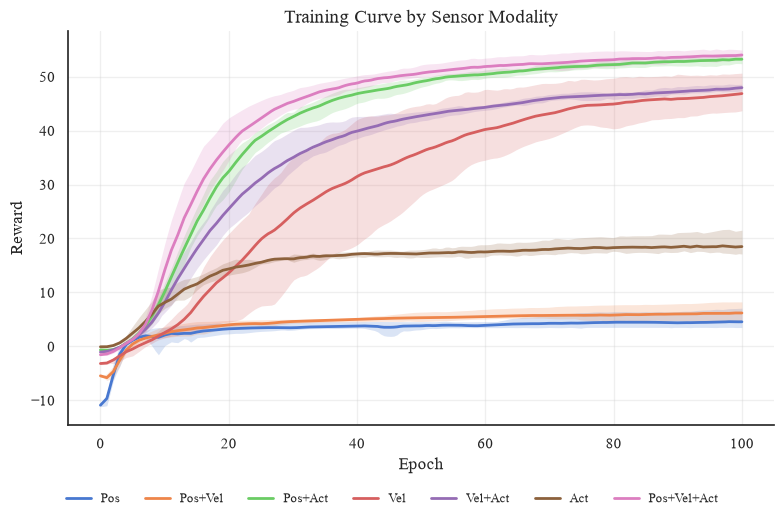

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def summarize_sensor_curve(sensor_df: pd.DataFrame, n_points: int = 200):
    """Interpolate each run's (step, mean) curve onto a shared step grid,
    then return step, mean/min/max across runs at each point."""
    run_curves = []
    for run_num, g in sensor_df.groupby("run_num"):
        g = g.dropna(subset=["step", "mean"]).sort_values("step")
        if len(g) == 0:
            continue
        run_curves.append((g["step"].to_numpy(), g["mean"].to_numpy()))

    if not run_curves:
        return None

    step_lo = max(steps.min() for steps, _ in run_curves)
    step_hi = min(steps.max() for steps, _ in run_curves)
    common_steps = np.linspace(step_lo, step_hi, n_points)

    interp = np.stack([
        np.interp(common_steps, steps, values) for steps, values in run_curves
    ])

    return common_steps, interp.mean(axis=0), interp.min(axis=0), interp.max(axis=0)


# ── Publication style (matches other figures in this repo) ────────────────
sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.edgecolor": "#2b2b2b",
    "grid.alpha": 0.30,
})

colors = sns.color_palette("muted", n_colors=len(label_map))

fig, ax = plt.subplots(figsize=(8, 5))

for sensor, color in zip(label_map.keys(), colors):
    result = summarize_sensor_curve(mean_df[mean_df["sensor"] == sensor])
    if result is None:
        print(f"Warning: no data for sensor {sensor}")
        continue
    step, curve_mean, curve_min, curve_max = result

    ax.fill_between(step, curve_min, curve_max, color=color, alpha=0.2, linewidth=0)
    ax.plot(step, curve_mean, color=color, linewidth=2, label=label_map.get(sensor, sensor))

ax.set_xlabel("Epoch")
ax.set_ylabel("Reward")
# ax.set_title("Training Curve by Sensor Modality\n(line = mean across runs, band = min–max)")
ax.set_title("Training Curve by Sensor Modality" , fontsize=14)
sns.despine()
# fig.legend(title="Sensor", loc="lower center", ncol=len(label_map), fontsize=10,
#            frameon=False, bbox_to_anchor=(0.5, -0.13))
fig.legend(loc="lower center", ncol=len(label_map), fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.tight_layout()

# fig.savefig("local_prop_train_reward.pdf", dpi=300, bbox_inches="tight")
fig.savefig("local_prop_train_reward.png", dpi=300, bbox_inches="tight")
plt.show()